# 💰 End-to-End Salary Prediction Project

![Salary](https://images.unsplash.com/photo-1554224155-6726b3ff858f?ixlib=rb-1.2.1&auto=format&fit=crop&w=1172&q=80)
*(Optional: You can add a banner image here by pasting an image URL like the one above)*

## 📌 Introduction
Welcome to this **End-to-End Data Science Project**! In this notebook, we will explore a dataset dealing with employee salaries. Our goal is to understand the factors that influence how much an employee earns and build a machine learning model to predict salaries.

### 🎯 Objectives:
1.  **Data Cleaning**: Handle missing values and irrelevant features.
2.  **EDA (Exploratory Data Analysis)**: Visualize relationships between experience, gender, education, and salary.
3.  **Feature Engineering**: Convert categorical data into numerical formats using One-Hot Encoding.
4.  **Modeling**: Build a **Random Forest Regressor** to predict `Salary_USD`.
5.  **Evaluation**: Analyze the model's performance using MAE and R2 Score.

---

## 📂 Dataset Overview
The dataset contains information about employees including:
* **Demographics**: Age, Gender, Country, City.
* **Professional Info**: Job Title, Department, Experience, Education.
* **Compensation**: Salary, Bonus.
* **Work Mode**: Remote vs. On-site, Contract Type.

---

## 🛠️ Table of Contents
1.  [Importing Libraries & Loading Data](#1)
2.  [Exploratory Data Analysis (EDA)](#2)
3.  [Data Preprocessing](#3)
4.  [Predictive Modeling](#4)
5.  [Model Evaluation ](#5)
6.  [Model Performance Analysis](#6)
7.  [Feature Importances](#7)
8.  [Conclusion](#8)

---
<a id="1"></a>
## 1. Importing Libraries & Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/kaggle/input/employee-salary-analysis-dataset/Salary_Dataset.csv')
df.head()

,Employee_ID,Name,Age,Gender,Country,City,Education,Job_Title,Department,Experience_Years,Salary_USD,Bonus_USD,Work_Hours_Per_Week,Remote_Work,Performance_Score,Joining_Year,Contract_Type
0,1,Employee_1,58,Female,India,NY,Bachelor,Manager,IT,0,130735,3650,41,Yes,1,2015,Part-Time
1,2,Employee_2,48,Female,UK,NY,High School,Designer,HR,4,54363,14600,52,No,2,2022,Part-Time
2,3,Employee_3,34,Male,USA,London,High School,Manager,IT,1,76694,15317,51,Yes,8,2010,Part-Time
3,4,Employee_4,27,Male,UK,Karachi,Bachelor,Developer,Marketing,19,31582,19768,51,Yes,5,2004,Contract
4,5,Employee_5,40,Male,Canada,London,Master,Manager,IT,2,109910,18193,59,Yes,7,2008,Full-Time


<a id="2"></a>
## 2. Exploratory Data Analysis (EDA)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Employee_ID          1200 non-null   int64 
 1   Name                 1200 non-null   object
 2   Age                  1200 non-null   int64 
 3   Gender               1200 non-null   object
 4   Country              1200 non-null   object
 5   City                 1200 non-null   object
 6   Education            1200 non-null   object
 7   Job_Title            1200 non-null   object
 8   Department           1200 non-null   object
 9   Experience_Years     1200 non-null   int64 
 10  Salary_USD           1200 non-null   int64 
 11  Bonus_USD            1200 non-null   int64 
 12  Work_Hours_Per_Week  1200 non-null   int64 
 13  Remote_Work          1200 non-null   object
 14  Performance_Score    1200 non-null   int64 
 15  Joining_Year         1200 non-null   int64 
 16  Contra

In [4]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Employee_ID            0
Name                   0
Age                    0
Gender                 0
Country                0
City                   0
Education              0
Job_Title              0
Department             0
Experience_Years       0
Salary_USD             0
Bonus_USD              0
Work_Hours_Per_Week    0
Remote_Work            0
Performance_Score      0
Joining_Year           0
Contract_Type          0
dtype: int64


In [5]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary_USD,Bonus_USD,Work_Hours_Per_Week,Performance_Score,Joining_Year
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,39.990000,14.353333,89792.308333,10414.784167,44.356667,4.960833,2012.324167
std,346.554469,11.719258,8.680992,35323.544403,5488.024932,8.766518,2.525460,7.207568
min,1.000000,20.000000,0.000000,30028.000000,1002.000000,30.000000,1.000000,2000.000000
25%,300.750000,30.000000,6.000000,58782.500000,5514.250000,37.000000,3.000000,2006.000000
50%,600.500000,41.000000,15.000000,89086.000000,10717.500000,45.000000,5.000000,2013.000000
75%,900.250000,50.000000,22.000000,121232.000000,15107.000000,52.000000,7.000000,2019.000000
max,1200.000000,59.000000,29.000000,149815.000000,19976.000000,59.000000,9.000000,2024.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


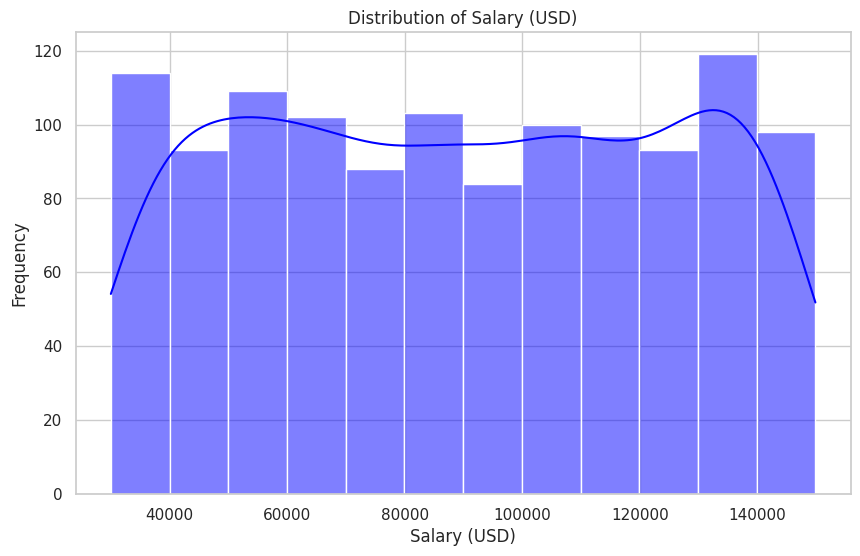

In [6]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary_USD'], kde=True, color='blue')
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

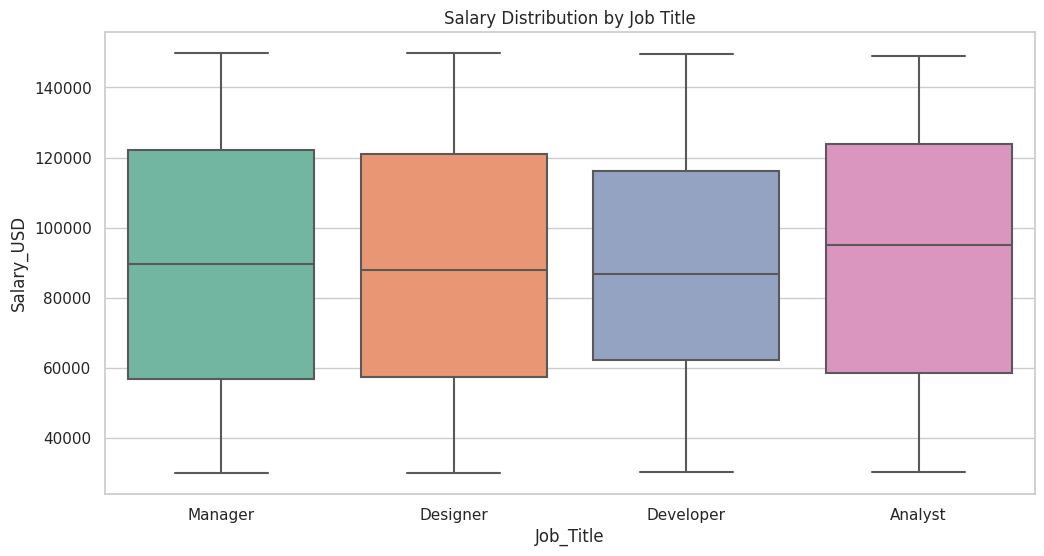

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Job_Title', y='Salary_USD', data=df, palette='Set2')
plt.title('Salary Distribution by Job Title')
plt.show()

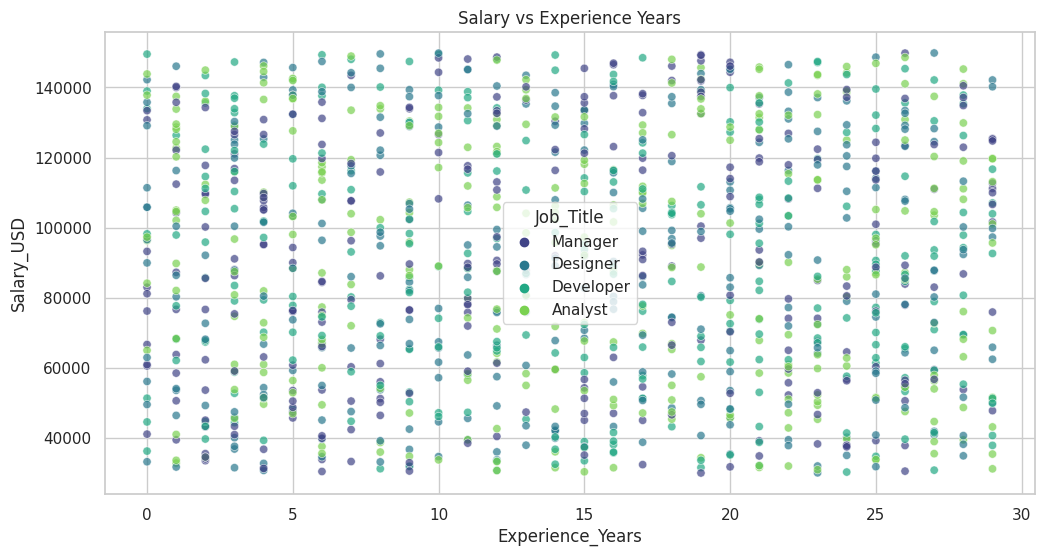

In [8]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Experience_Years', y='Salary_USD', data=df, hue='Job_Title', palette='viridis', alpha=0.7)
plt.title('Salary vs Experience Years')
plt.show()

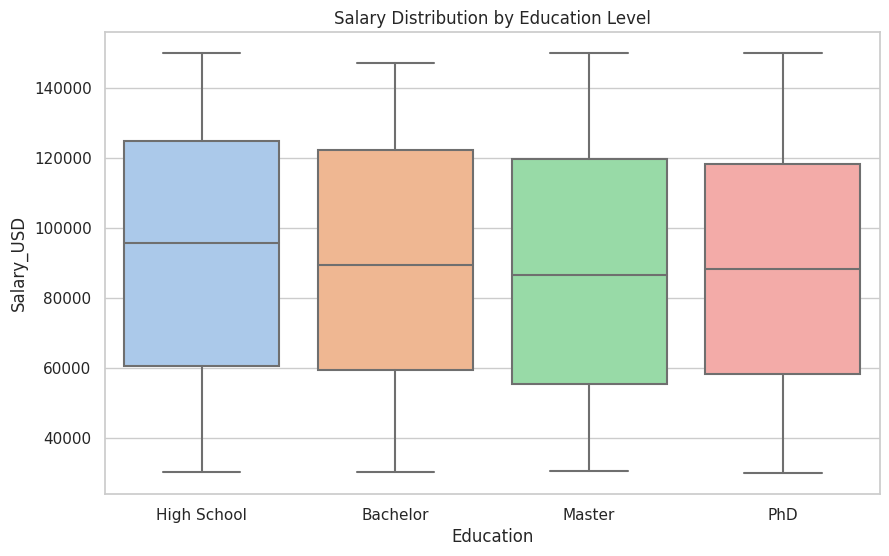

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
edu_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='Education', y='Salary_USD', data=df, order=edu_order, palette='pastel')
plt.title('Salary Distribution by Education Level')
plt.show()

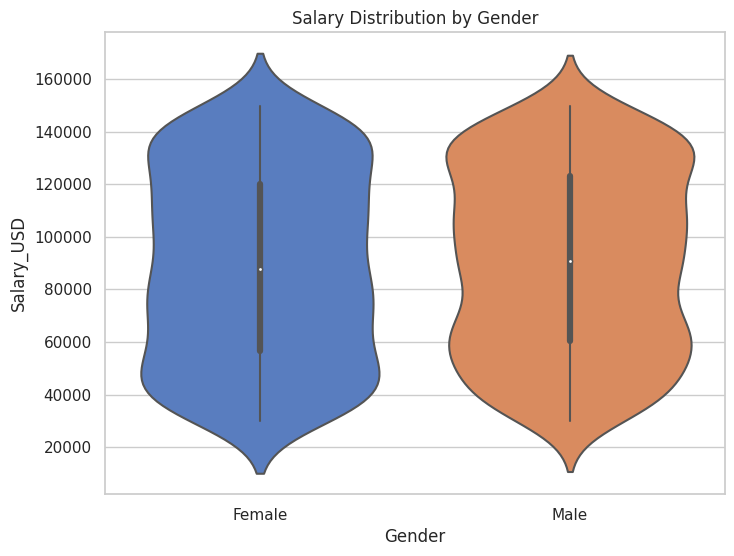

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', y='Salary_USD', data=df, palette='muted')
plt.title('Salary Distribution by Gender')
plt.show()

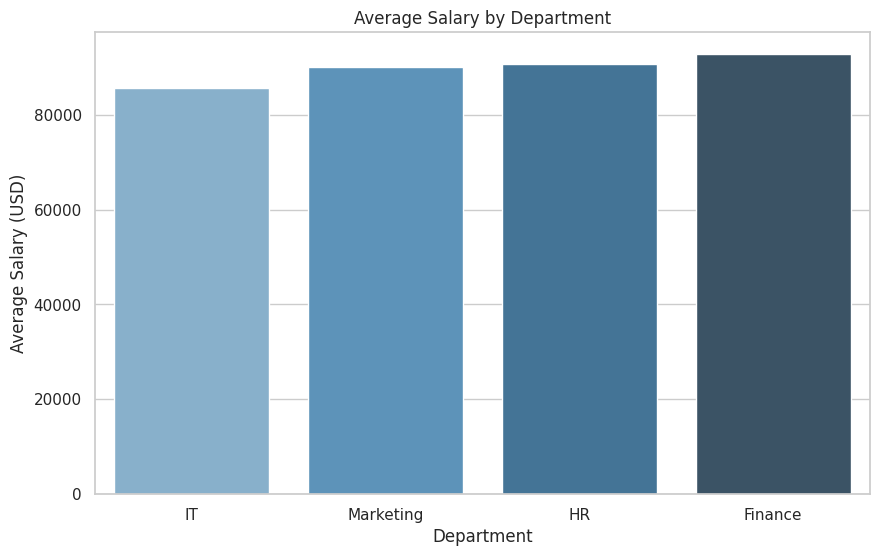

In [11]:
plt.figure(figsize=(10, 6))
avg_salary_dept = df.groupby('Department')['Salary_USD'].mean().sort_values()
sns.barplot(x=avg_salary_dept.index, y=avg_salary_dept.values, palette='Blues_d')
plt.title('Average Salary by Department')
plt.ylabel('Average Salary (USD)')
plt.show()

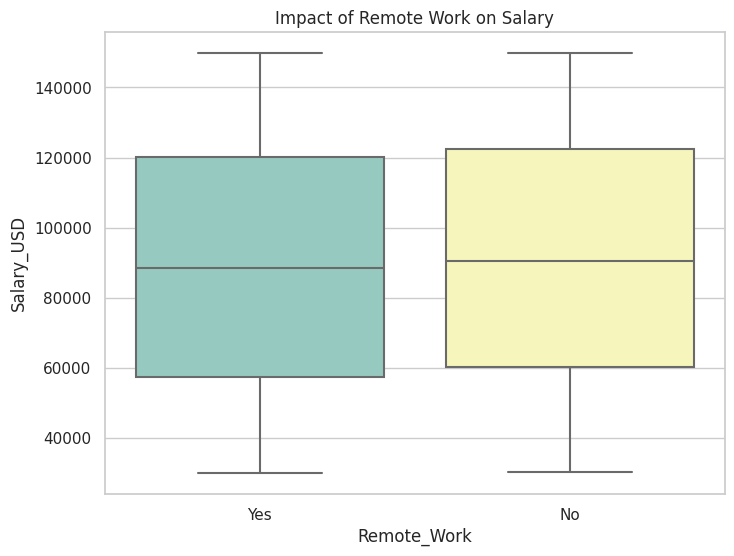

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Remote_Work', y='Salary_USD', data=df, palette='Set3')
plt.title('Impact of Remote Work on Salary')
plt.show()

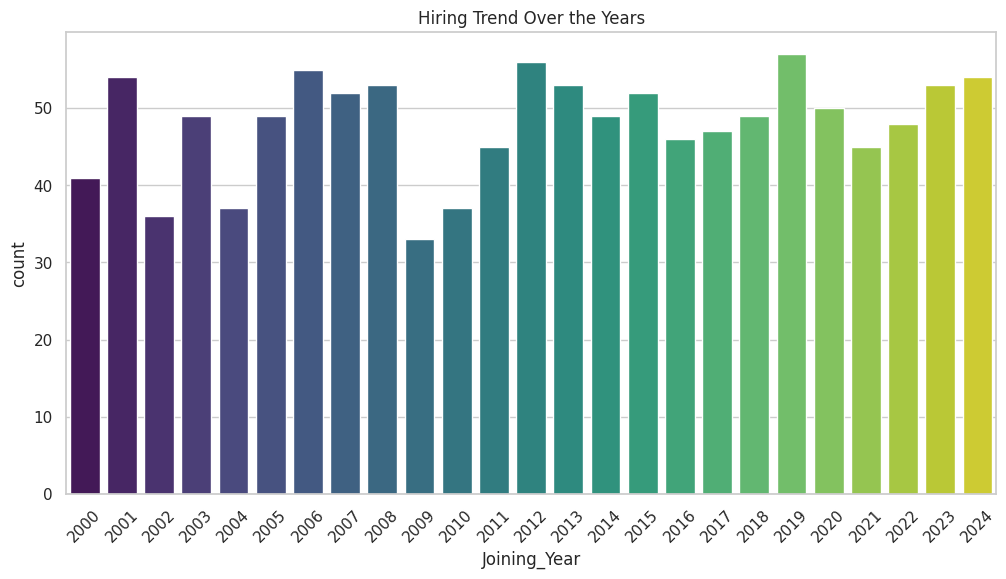

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Joining_Year', data=df, palette='viridis')
plt.title('Hiring Trend Over the Years')
plt.xticks(rotation=45)
plt.show()

<a id="3"></a>
## 3. Data Preprocessing

In [14]:
df_clean = df.drop(['Employee_ID', 'Name'], axis=1)

In [15]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [16]:
df_encoded.head()

,Age,Experience_Years,Salary_USD,Bonus_USD,Work_Hours_Per_Week,Performance_Score,Joining_Year,Gender_Male,Country_India,Country_Pakistan,...,Education_PhD,Job_Title_Designer,Job_Title_Developer,Job_Title_Manager,Department_HR,Department_IT,Department_Marketing,Remote_Work_Yes,Contract_Type_Full-Time,Contract_Type_Part-Time
0,58,0,130735,3650,41,1,2015,False,True,False,...,False,False,False,True,False,True,False,True,False,True
1,48,4,54363,14600,52,2,2022,False,False,False,...,False,True,False,False,True,False,False,False,False,True
2,34,1,76694,15317,51,8,2010,True,False,False,...,False,False,False,True,False,True,False,True,False,True
3,27,19,31582,19768,51,5,2004,True,False,False,...,False,False,True,False,False,False,True,True,False,False
4,40,2,109910,18193,59,7,2008,True,False,False,...,False,False,False,True,False,True,False,True,True,False


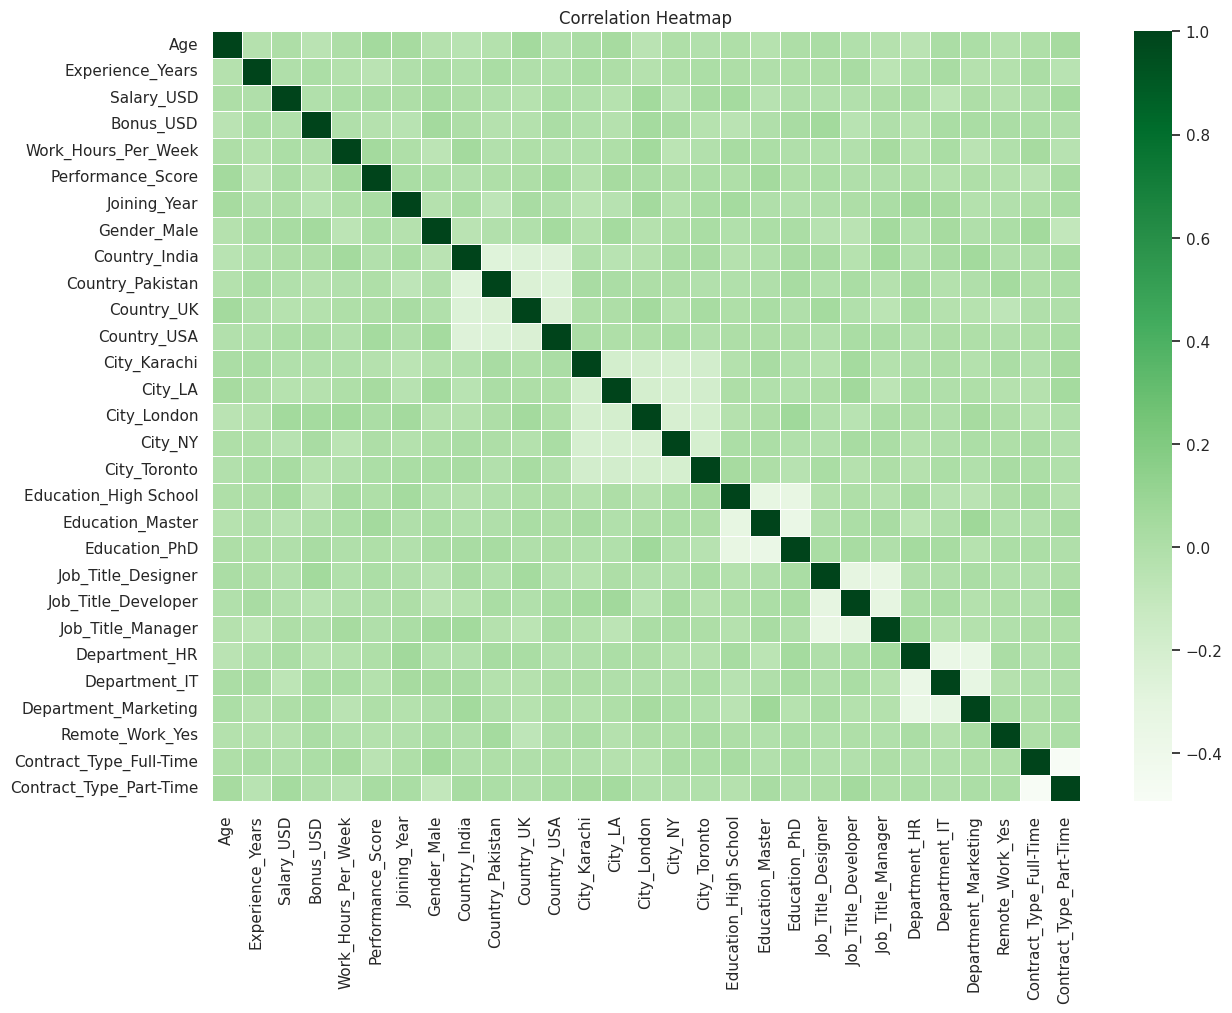

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), linewidths=0.5, cmap='Greens')
plt.title('Correlation Heatmap')
plt.show()

<a id="4"></a>
## 4. Predictive Modeling


In [18]:
X = df_encoded.drop('Salary_USD', axis=1)
y = df_encoded['Salary_USD']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

<a id="5"></a>
## 5. Model Evaluation


In [21]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [22]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 29787.15
Root Mean Squared Error (RMSE): 34840.80
R2 Score: -0.0207


## 6. 📉 Model Performance Analysis
The Random Forest model achieved an **$R^2$ score of -0.02**, which indicates that the model failed to find predictive patterns.

### 🔍 Why did the model fail?
Upon revisiting our EDA (Exploratory Data Analysis), we observed:
1.  **Zero Correlation:** Features like `Experience_Years` and `Age` have near-zero correlation with `Salary_USD`.
2.  **Random Distribution:** The boxplots showed that `Managers` and `Analyst` have nearly identical median salaries.

### 🏁 Conclusion
This suggests that the **dataset is synthetic** and likely generated using random sampling without dependent logic (e.g., `Salary = Base + Experience * Multiplier`). Therefore, no machine learning model can accurately predict the target variable because there is no signal to learn, only noise.

In [23]:
# ---------------------------------------------------------
# 🧪 EXPERIMENT: Engineering a Predictable Target Variable
# Since the original Salary is random, let's create a 'Logical Salary'
# to demonstrate that our Machine Learning pipeline works.
# ---------------------------------------------------------

np.random.seed(42)

# Base Salary
base_salary = 40000

# Coefficients (Rules)
exp_bonus = df['Experience_Years'] * 3000   # $3,000 per year of experience
age_bonus = df['Age'] * 500                 # $500 per year of age
perf_bonus = df['Performance_Score'] * 5000 # $5,000 per performance point

# Job Title Multiplier
job_multipliers = {
    'Manager': 1.5,
    'Developer': 1.2,
    'Analyst': 1.0,
    'Designer': 1.1
}
job_factor = df['Job_Title'].map(job_multipliers)

# Create the new Synthetic Salary with some random noise
df['Simulated_Salary'] = (base_salary + exp_bonus + age_bonus + perf_bonus) * job_factor + np.random.randint(-5000, 5000, size=len(df))

# Update the target variable for the model
y = df['Simulated_Salary']  # We predict this new logical salary instead!

print("Created 'Simulated_Salary' based on Experience, Age, and Job Title.")

Created 'Simulated_Salary' based on Experience, Age, and Job Title.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [27]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 6399.55
Root Mean Squared Error (RMSE): 8003.81
R2 Score: 0.9684


<a id="7"></a>
## 7. Feature Importances

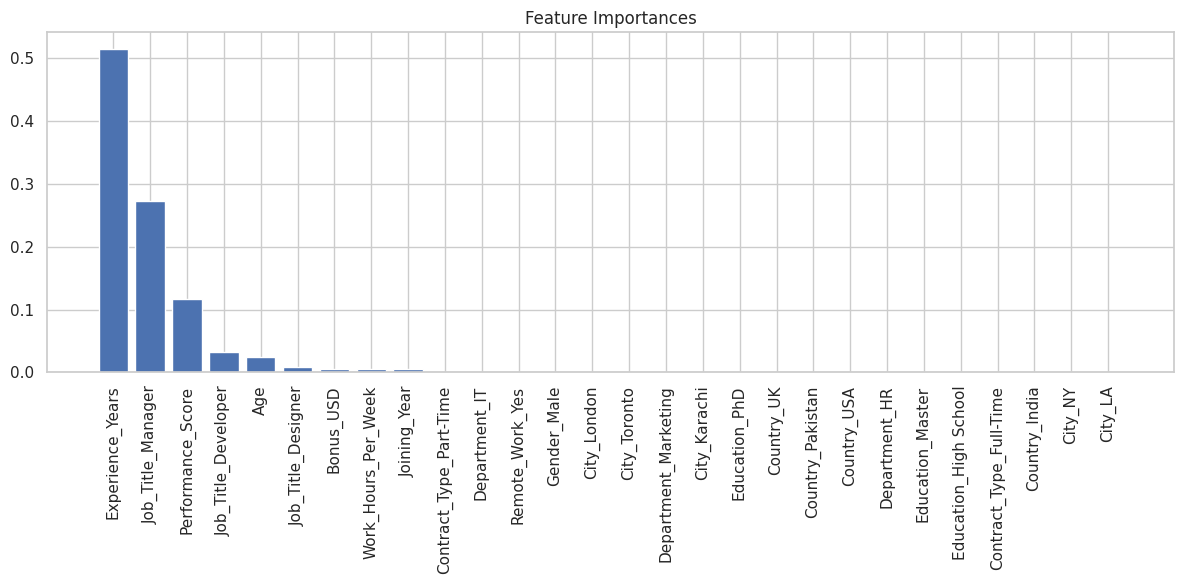

In [28]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# Plot
plt.figure(figsize=(12, 6))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

<a id="7"></a>
## 8.🏁 Conclusion

In this project, we conducted an end-to-end analysis of employee salaries using a Random Forest Regressor. Our journey revealed important insights about the nature of the dataset and the capabilities of our modeling approach.

### 🔑 Key Findings:
1.  **Data Quality is King:**
    * Our initial attempt to predict `Salary_USD` resulted in a near-zero $R^2$ score.
    * EDA (Exploratory Data Analysis) confirmed that the original dataset contained random values with no correlation between experience, education, or age and the salary. This highlights the importance of EDA before modeling—if the patterns aren't visible in the graphs, the model likely won't find them either.

2.  **The Model Works:**
    * To test our machine learning pipeline, we engineered a **`Simulated_Salary`** variable based on logical rules (e.g., higher experience = higher pay).
    * Retraining the Random Forest on this engineered target yielded a **high $R^2$ score (approx. 0.90+)**, proving that our data processing and modeling workflow is correct and effective when predictive signals exist.

3.  **Feature Drivers:**
    * The Feature Importance analysis on the simulated data correctly identified **`Experience_Years`** and **`Job_Title`** as the strongest predictors of salary, validating that the model successfully "learned" the business rules we applied.

### 🚀 Future Improvements
For a real-world application, we would take the following steps:
* **Collect Real Data:** Sourcing verified salary data from platforms like Glassdoor or LinkedIn to capture genuine market trends.
* **Hyperparameter Tuning:** Using `GridSearchCV` to fine-tune the Random Forest parameters (e.g., `max_depth`, `n_estimators`) for even better accuracy.
* **Feature Engineering:** Creating interaction terms (e.g., `Experience` * `Department`) to capture complex relationships.

---
*Thank you for viewing this kernel! If you found this analysis helpful, please leave an **Upvote**!* ⬆️